In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats

In [ ]:
df = pd.read_csv("/content/Actual_39.95_-104.65_2006_UPV_100MW_5_Min.csv")

In [ ]:
df['LocalTime'] = pd.to_datetime(df['LocalTime'])

<ipython-input-6-dd226080c5c0>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['LocalTime'] = pd.to_datetime(df['LocalTime'])


In [ ]:
df1 = df.groupby(pd.Grouper(key='LocalTime', freq='30T')).mean().reset_index()

<ipython-input-7-87b8066fc763>:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df1 = df.groupby(pd.Grouper(key='LocalTime', freq='30T')).mean().reset_index()


In [ ]:
df1.set_index('LocalTime', inplace=True)

In [ ]:
df1.head()

,Power(MW)
LocalTime,
2006-01-01 00:00:00,0.0
2006-01-01 00:30:00,0.0
2006-01-01 01:00:00,0.0
2006-01-01 01:30:00,0.0
2006-01-01 02:00:00,0.0


In [ ]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Load the data (assuming `df` contains the target column 'power_output')
time_series = df1

# ADF Test
adf_test = adfuller(time_series)
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

if adf_test[1] > 0.05:
    print("The time series is non-stationary. Differencing may be required.")
else:
    print("The time series is stationary.")

ADF Statistic: -8.557343142200082
p-value: 8.885542783901404e-14
The time series is stationary.


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 20.5 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

# Fit ARIMA using auto_arima to determine the best (p, d, q)
model_auto = auto_arima(time_series, seasonal=False, trace=True, stepwise=True)
print("Best ARIMA parameters:", model_auto.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=112224.785, Time=27.82 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=115789.083, Time=1.94 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=112573.756, Time=2.21 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=113210.260, Time=5.54 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=115787.083, Time=0.48 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=112251.338, Time=16.30 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=112275.721, Time=18.06 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=70.65 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=63.65 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=112322.692, Time=7.69 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=112181.611, Time=15.77 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=112594.093, Time=10.36 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=112134.791, Time=21.47 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=112310.148, Time=14.11 sec
 ARIMA(2,1

In [ ]:
from statsmodels.tsa.arima.model import ARIMA


# Fit ARIMA model
arima_model = ARIMA(time_series, order=(2, 1, 4))
arima_result = arima_model.fit()
print(arima_result.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:              Power(MW)   No. Observations:                17520
Model:                 ARIMA(2, 1, 4)   Log Likelihood              -55068.204
Date:                Wed, 20 Nov 2024   AIC                         110150.408
Time:                        09:04:42   BIC                         110204.806
Sample:                    01-01-2006   HQIC                        110168.320
                         - 12-31-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.9523      0.002   1051.642      0.000       1.949       1.956
ar.L2         -0.9708      0.002   -515.540      0.000      -0.975      -0.967
ma.L1         -1.7128      0.004   -467.818      0.0

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Make predictions (in-sample)
predictions = arima_result.predict(start=1, end=len(time_series) - 1)

# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(time_series[1:], predictions))
mae = mean_absolute_error(time_series[1:], predictions)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


RMSE: 5.6101
MAE: 3.4535


In [ ]:
# Forecast future values
forecast_steps = 48  # Forecast the next 48 time steps (1 day of 30-min intervals)
forecast = arima_result.forecast(steps=forecast_steps)



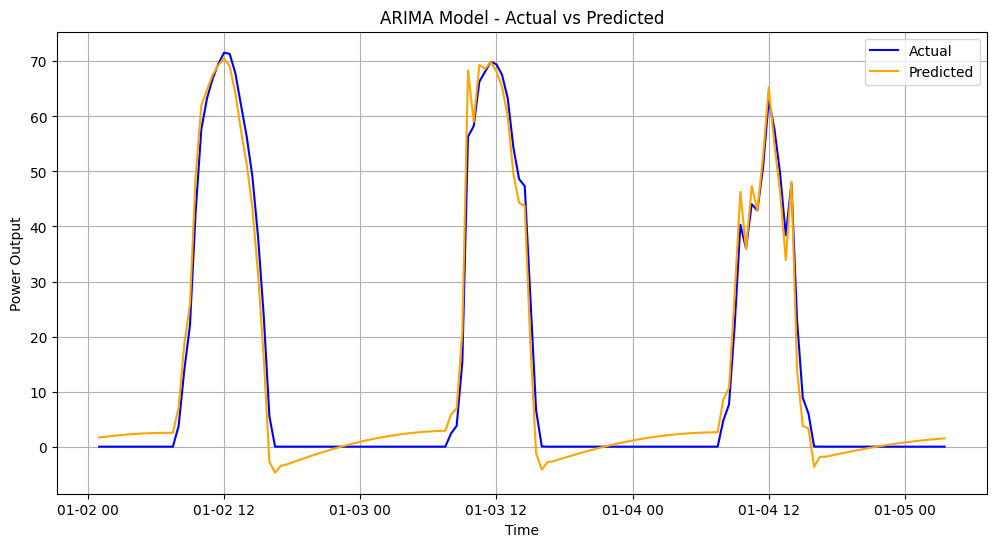

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs predictions
plt.figure(figsize=(12, 6))
plt.plot(time_series.index[50:200], time_series[50:200], label="Actual", color="blue")
plt.plot(time_series.index[50:200], predictions[50:200], label="Predicted", color="orange")

# Add forecast
#forecast_index = pd.date_range(start=time_series.index[-1], periods=forecast_steps + 1, freq='30min')[1:]
#plt.plot(forecast_index, forecast, label="Forecast", color="green", linestyle='--')

plt.title("ARIMA Model - Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Power Output")
plt.legend()
plt.grid()
plt.show()


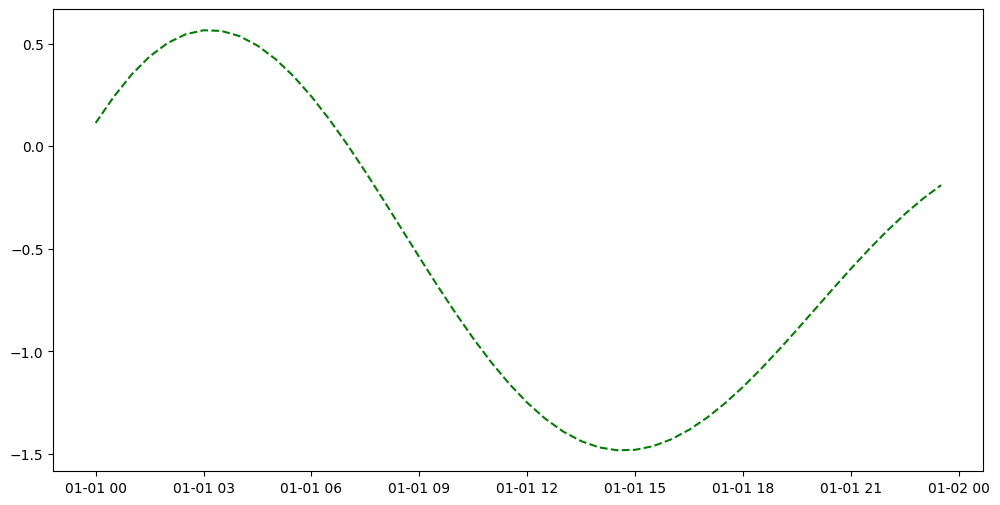

In [ ]:
plt.figure(figsize=(12, 6))
forecast_index = pd.date_range(start=time_series.index[-1], periods=forecast_steps + 1, freq='30min')[1:]
plt.plot(forecast_index, forecast, label="Forecast", color="green", linestyle='--')